In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path
ROOT = Path.cwd().parent
RAW = ROOT / "data" / "raw"
print([f.name for f in RAW.glob("*.csv")])

ROOT = Path.cwd().parent
RAW = ROOT / "data" / "raw"
riders = pd.read_csv(RAW / "riders.csv")
trips  = pd.read_csv(RAW / "trips.csv")  

['drivers.csv', 'promotions.csv', 'riders.csv', 'sessions.csv', 'trips.csv', 'trips_sample.csv']


In [3]:
# Preview first 5 rows of each dataset
print("Riders")
display(riders.head())
print("\nTrips")
display(trips.head())

Riders


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,NaN
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,NaN
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002



Trips


,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 23:13:48+00:14,2024-10-28 23:26:48+00:14,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 05:36:41+02:27,2025-02-17 05:52:41+02:27,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 19:27:14+02:05,2024-06-18 19:32:14+02:05,29.819554,31.188780,29.837689,31.232978,Cloudy,Cairo,Bronze
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 09:58:16+02:27,2024-10-05 10:28:16+02:27,-1.676479,36.729219,-1.638395,36.694063,Sunny,Nairobi,Gold


In [4]:
# Shape of each dataset
print("Riders shape:", riders.shape)
print("Trips shape:", trips.shape)

Riders shape: (10000, 8)
Trips shape: (200000, 16)


In [5]:
# Data types and null values
print("\nRiders info")
riders.info()
print("\nTrips info")
trips.info()


Riders info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           10000 non-null  object 
 1   signup_date       10000 non-null  object 
 2   loyalty_status    10000 non-null  object 
 3   age               10000 non-null  float64
 4   city              10000 non-null  object 
 5   avg_rating_given  10000 non-null  float64
 6   churn_prob        10000 non-null  float64
 7   referred_by       3053 non-null   object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB

Trips info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   trip_id           200000 non-null  object 
 1   user_id           200000 non-null  object 
 2   driver_id         200000 non-null  o

In [6]:
# Summary statistics
display(riders.describe())
display(trips.describe())

,age,avg_rating_given,churn_prob
count,10000.000000,10000.000000,10000.000000
mean,35.154221,4.461510,0.286168
std,9.545528,0.429162,0.159029
min,18.000000,2.600000,0.002934
25%,28.317568,4.200000,0.161691
50%,35.037671,4.500000,0.266712
75%,41.691186,4.800000,0.388812
max,70.000000,5.000000,0.913302


,fare,surge_multiplier,tip,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,15.401285,1.141500,0.469566,11.849600,23.924133,11.849589,23.924173
std,6.163199,0.255362,1.100545,13.362151,14.577572,13.362229,14.577642
min,2.970000,1.000000,0.000000,-1.786360,2.879224,-1.833220,2.830979
25%,11.000000,1.000000,0.000000,-1.172683,3.496574,-1.172868,3.497195
50%,14.130000,1.000000,0.000000,6.525574,31.238814,6.525235,31.239118
75%,18.350000,1.200000,0.400000,29.934766,36.703772,29.935056,36.704067
max,82.740000,3.800000,21.860000,30.544251,37.317090,30.592457,37.364817


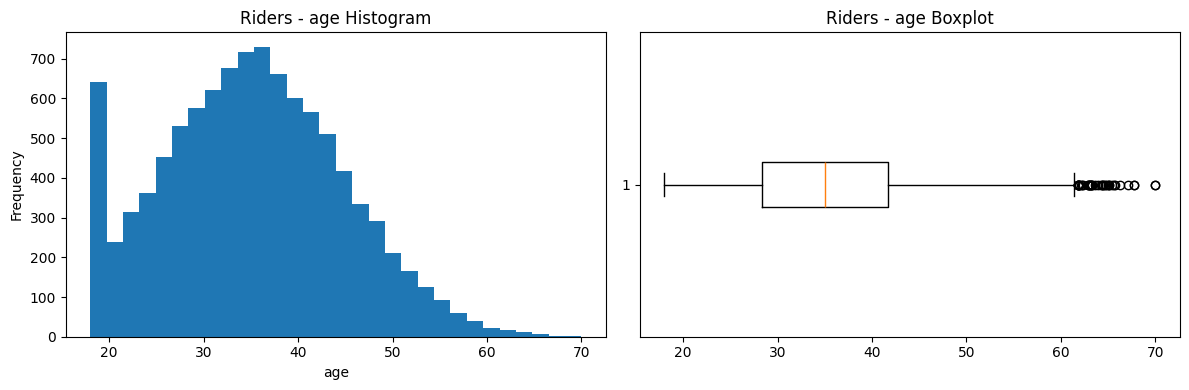

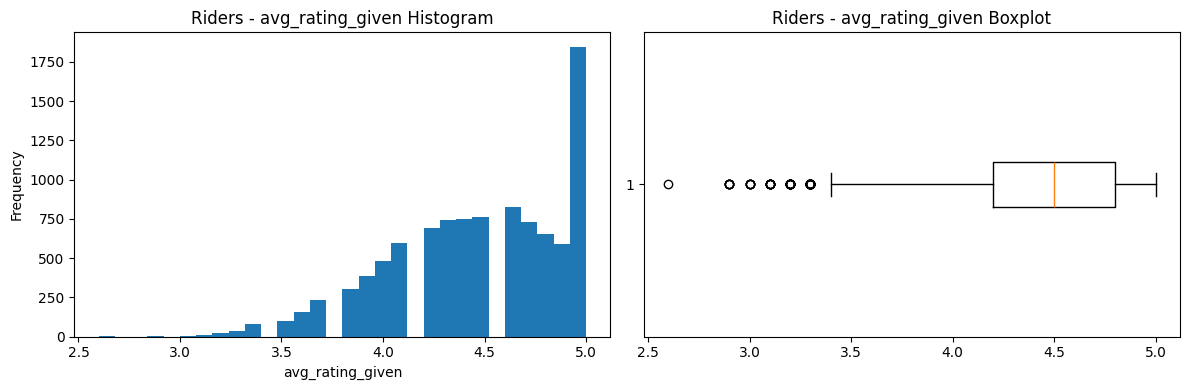

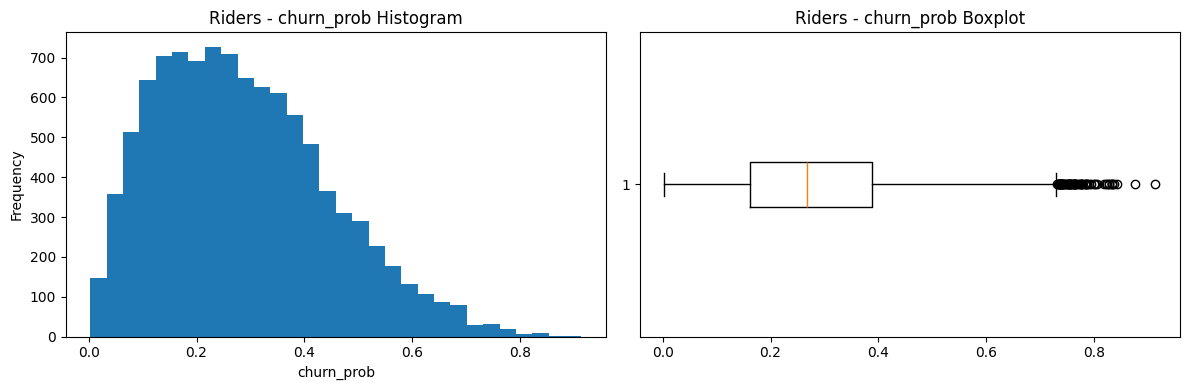

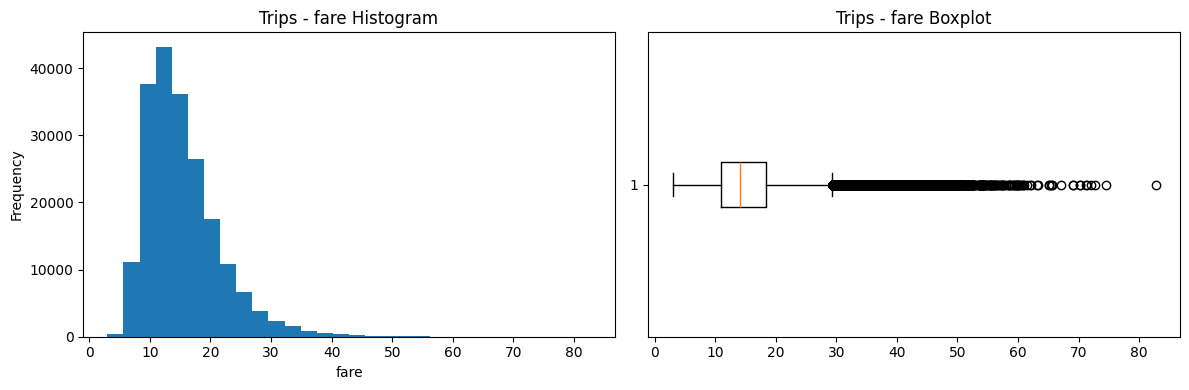

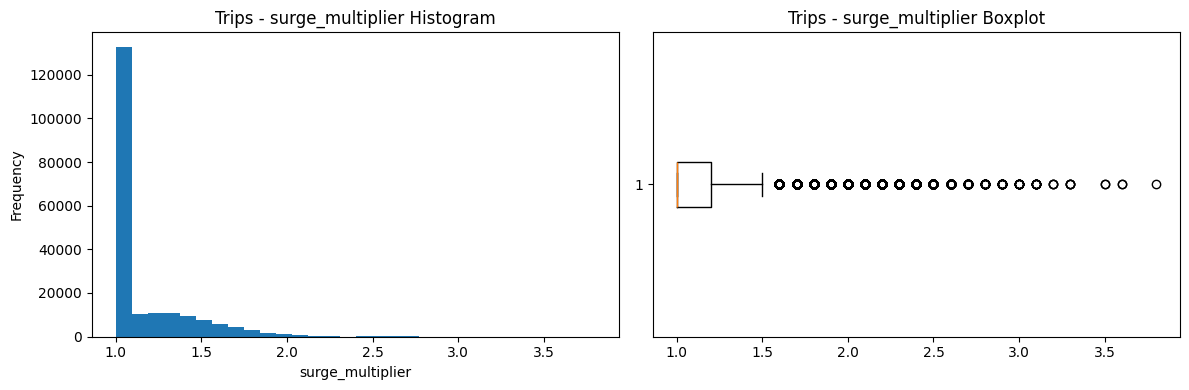

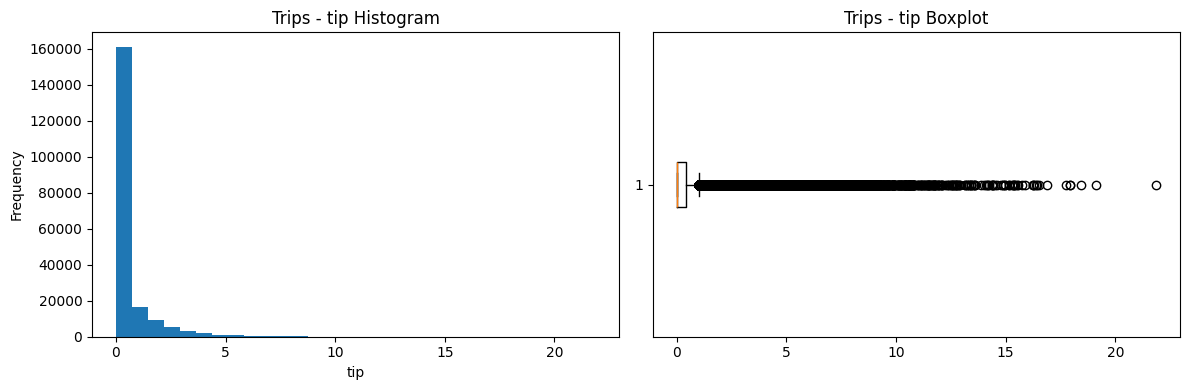

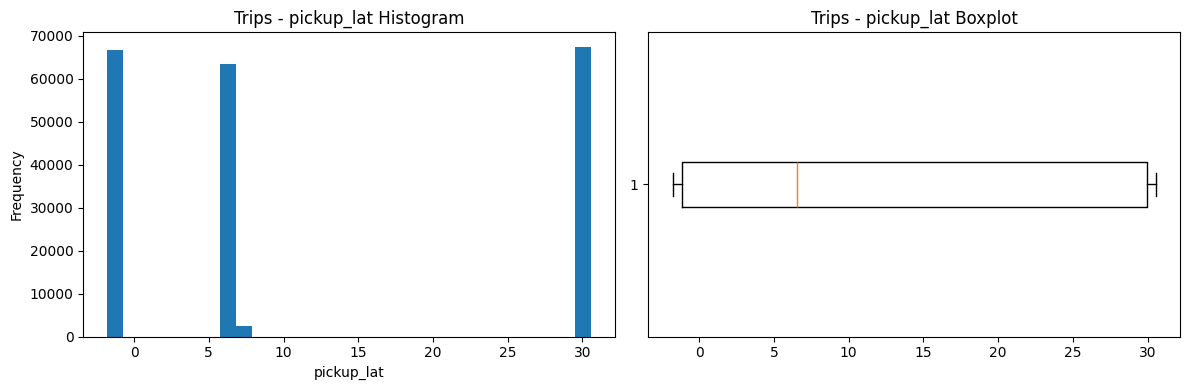

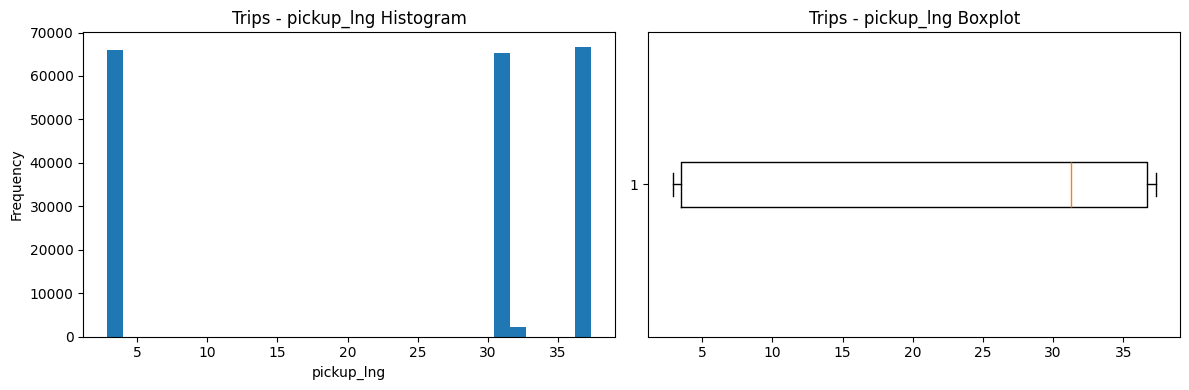

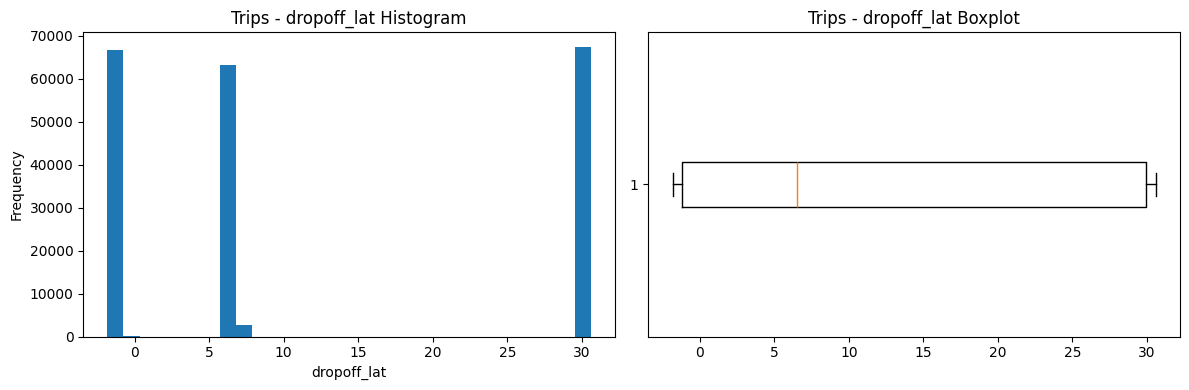

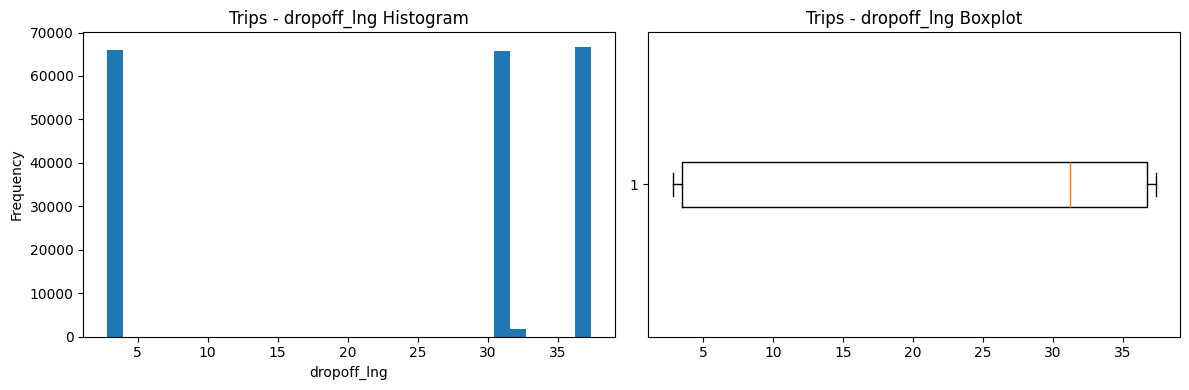

In [7]:
# Function to get numerical columns
def get_numerical_columns(df):
    return df.select_dtypes(include=["int64", "float64"]).columns
get_numerical_columns(riders)
get_numerical_columns(trips)

num_cols_riders = get_numerical_columns(riders)

for col in num_cols_riders:
    plt.figure(figsize=(12,4))

    # Histogram
    plt.subplot(1,2,1)
    plt.hist(riders[col].dropna(), bins=30)
    plt.title(f"Riders - {col} Histogram")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    # Boxplot
    plt.subplot(1,2,2)
    plt.boxplot(riders[col].dropna(), vert=False)
    plt.title(f"Riders - {col} Boxplot")

    plt.tight_layout()
    plt.show()

    num_cols_trips = get_numerical_columns(trips)

for col in num_cols_trips:
    plt.figure(figsize=(12,4))

    # Histogram
    plt.subplot(1,2,1)
    plt.hist(trips[col].dropna(), bins=30)
    plt.title(f"Trips - {col} Histogram")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    # Boxplot
    plt.subplot(1,2,2)
    plt.boxplot(trips[col].dropna(), vert=False)
    plt.title(f"Trips - {col} Boxplot")

    plt.tight_layout()
    plt.show()


In [8]:
# Function to display categorical value counts
def categorical_summary(df, df_name):
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    print(f"\n{df_name} - Categorical Summary\n")
    for col in cat_cols:
        print(f"\n{col}")
        print(df[col].value_counts())
categorical_summary(trips, "Trips")
categorical_summary(riders, "Riders")


Trips - Categorical Summary


trip_id
trip_id
T000000    1
T000001    1
T000002    1
T000003    1
T000004    1
          ..
T199995    1
T199996    1
T199997    1
T199998    1
T199999    1
Name: count, Length: 200000, dtype: int64

user_id
user_id
R08152    42
R06728    39
R09210    38
R09293    37
R09908    37
          ..
R01782     7
R06836     7
R03232     6
R01184     6
R00197     6
Name: count, Length: 10000, dtype: int64

driver_id
driver_id
D03093    67
D01999    66
D01107    65
D02137    65
D02429    63
          ..
D01358    21
D02377    21
D02879    21
D04528    19
D00728    19
Name: count, Length: 5000, dtype: int64

payment_type
payment_type
Card            100326
Mobile Money     79661
Cash             20013
Name: count, dtype: int64

pickup_time
pickup_time
2024-10-20 09:22:52+02:27    2
2024-12-05 21:43:33+00:14    2
2024-05-30 06:08:52+02:27    2
2024-11-27 08:26:48+00:14    2
2024-07-06 18:01:33+02:27    2
                            ..
2025-03-19 17:51:52+02:27    1

In [9]:
# Missing values summary
def missing_summary(df, name):
    print(f"\n{name} Missing Values Summary")
    print("-" * 40)
    missing_count = df.isnull().sum()
    missing_percent = (df.isnull().sum() / len(df)) * 100
    summary = pd.DataFrame({
        "Missing Count": missing_count,
        "Missing %": missing_percent
    }) 
    summary = summary[summary["Missing Count"] > 0].sort_values(by="Missing %", ascending=False)
    if summary.empty:
        print("No missing values 🎉")
    else:
        display(summary)
missing_summary(riders, "Riders")
missing_summary(trips, "Trips")



Riders Missing Values Summary
----------------------------------------


,Missing Count,Missing %
referred_by,6947,69.47



Trips Missing Values Summary
----------------------------------------
No missing values 🎉


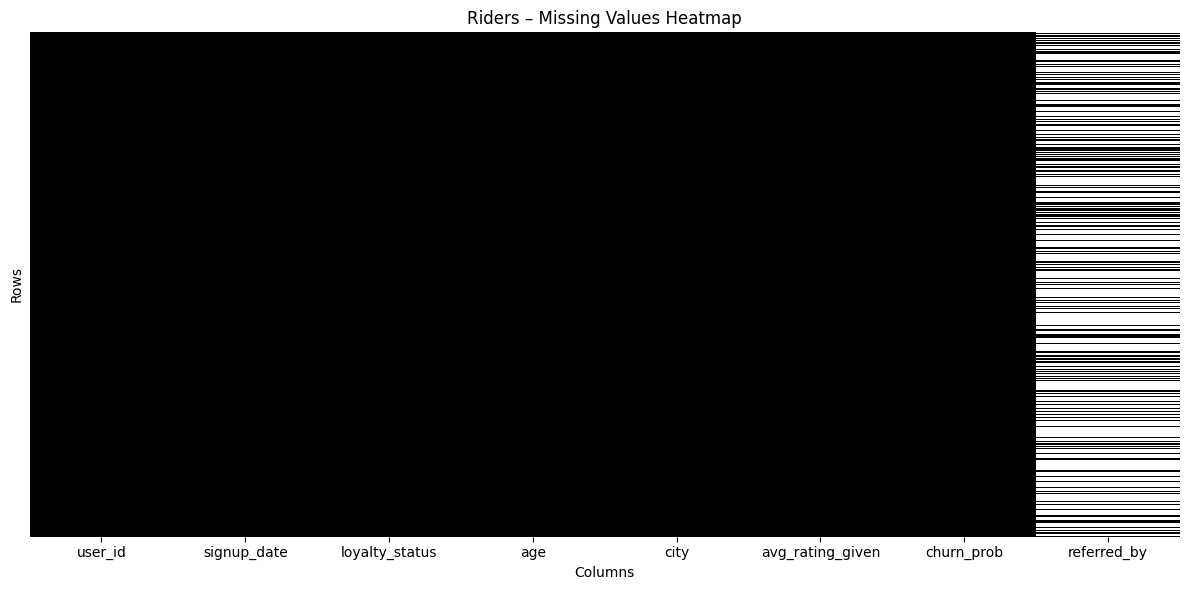

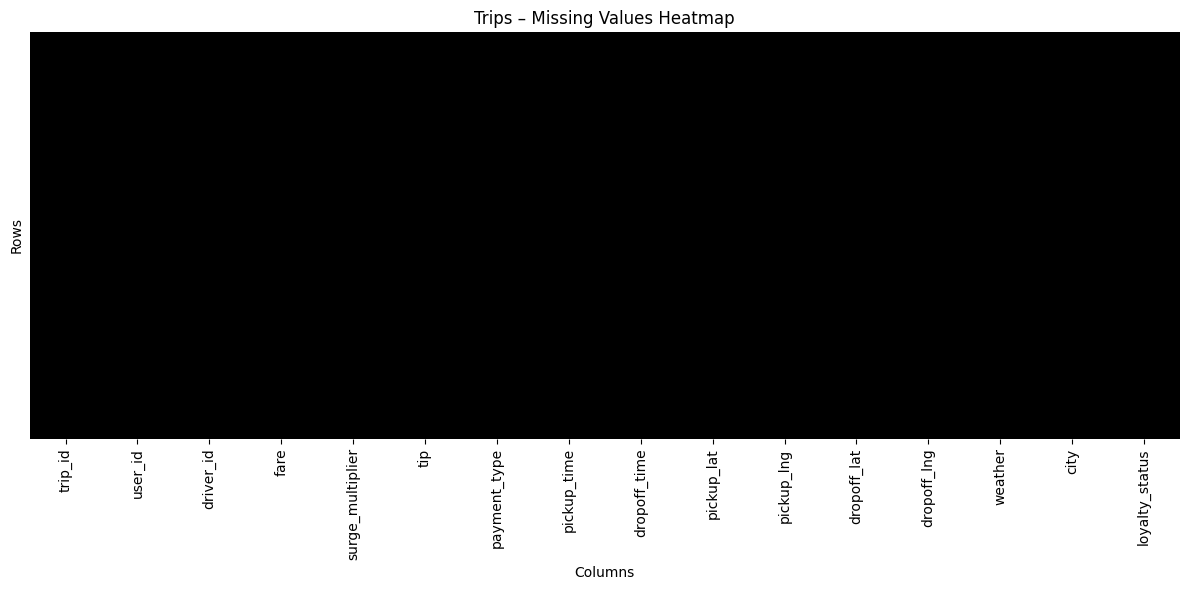

In [10]:
# Heatmap for missing values (gray & white theme)
def missing_values_heatmap(df, df_name):
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        df.isna(),
        cbar=False,
        cmap="gray",
        yticklabels=False
    )
    plt.title(f"{df_name} – Missing Values Heatmap")
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.tight_layout()
    plt.show()
# Apply to datasets
missing_values_heatmap(riders, "Riders")
missing_values_heatmap(trips, "Trips")


In [11]:
# Convert datetime columns
# Riders
riders["signup_date"] = pd.to_datetime(riders["signup_date"], errors="coerce")
# Trips
trips["pickup_time"] = pd.to_datetime(trips["pickup_time"], errors="coerce")
trips["dropoff_time"] = pd.to_datetime(trips["dropoff_time"], errors="coerce")

# Convert all remaining object columns to pandas string dtype
def convert_objects_to_string(df):
    obj_cols = df.select_dtypes(include="object").columns
    df[obj_cols] = df[obj_cols].astype("string")
    return df
# Apply to datasets
riders = convert_objects_to_string(riders)
trips = convert_objects_to_string(trips)

print("\nRiders info")
riders.info()
print("\nTrips info")
trips.info()


C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\664310090.py:5: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  trips["pickup_time"] = pd.to_datetime(trips["pickup_time"], errors="coerce")
C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\664310090.py:6: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  trips["dropoff_time"] = pd.to_datetime(trips["dropoff_time"], errors="coerce")



Riders info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           10000 non-null  string        
 1   signup_date       10000 non-null  datetime64[ns]
 2   loyalty_status    10000 non-null  string        
 3   age               10000 non-null  float64       
 4   city              10000 non-null  string        
 5   avg_rating_given  10000 non-null  float64       
 6   churn_prob        10000 non-null  float64       
 7   referred_by       3053 non-null   string        
dtypes: datetime64[ns](1), float64(3), string(4)
memory usage: 625.1 KB

Trips info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   trip_id           200000 non-null  string 
 

In [12]:
# =========================================
# FEATURE ENGINEERING (Riders + Trips) - FULL
# Timezone-safe recency calculation
# =========================================

riders = riders.copy()
trips  = trips.copy()

# -----------------------------
# 1) RIDERS: parse dates + lifecycle features
# -----------------------------
riders["signup_date"] = pd.to_datetime(riders["signup_date"], errors="coerce")

# Choose a stable reference date for recency/tenure
as_of = riders["signup_date"].max()
if pd.isna(as_of):
    as_of = pd.Timestamp.today().normalize()

# Make as_of tz-naive (always safe)
as_of = pd.to_datetime(as_of, errors="coerce")
if hasattr(as_of, "tzinfo") and as_of.tzinfo is not None:
    as_of = as_of.tz_localize(None)

riders["tenure_days"] = (as_of - riders["signup_date"]).dt.days
riders["signup_month"] = riders["signup_date"].dt.month
riders["signup_weekday"] = riders["signup_date"].dt.day_name()

riders["is_loyalty_member"] = riders["loyalty_status"].astype(str).str.lower().isin(
    ["yes", "true", "1", "member", "gold", "silver"]
)

riders["age_band"] = pd.cut(
    riders["age"],
    bins=[0, 18, 25, 35, 45, 55, 65, 120],
    labels=["<18","18-24","25-34","35-44","45-54","55-64","65+"],
    right=False
)

# -----------------------------
# 2) TRIPS: must include user_id
# -----------------------------
if "user_id" not in trips.columns:
    raise ValueError("Trips must include user_id for user-level aggregation. Reload trips and keep user_id.")

# -----------------------------
# 3) Detect trip datetime column
# -----------------------------
possible_dt_cols = [
    c for c in trips.columns
    if any(k in c.lower() for k in ["date", "time", "created", "start", "pickup"])
]

trip_dt_col = None
for c in possible_dt_cols:
    parsed = pd.to_datetime(trips[c], errors="coerce")
    if parsed.notna().mean() > 0.6:
        trips[c] = parsed
        trip_dt_col = c
        break

print("Detected trip datetime column:", trip_dt_col)

# -----------------------------
# 4) Aggregate trips per user
# -----------------------------
trip_agg = trips.groupby("user_id").agg(
    total_trips=("user_id", "size")
).reset_index()

if trip_dt_col is not None:
    # Ensure datetime
    trips[trip_dt_col] = pd.to_datetime(trips[trip_dt_col], errors="coerce")

    # If trips datetime is tz-aware, remove timezone
    if trips[trip_dt_col].dt.tz is not None:
        trips[trip_dt_col] = trips[trip_dt_col].dt.tz_localize(None)

# ==============================
# Referral Feature
# ==============================

# Convert referral column into a binary feature
riders["was_referred"] = riders["referred_by"].notna().astype(int)

print("Referral feature created ✅")
riders[["referred_by", "was_referred"]].head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\3279154106.py:55: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  parsed = pd.to_datetime(trips[c], errors="coerce")


Detected trip datetime column: pickup_time
Referral feature created ✅


,referred_by,was_referred
0,R00001,1
1,<NA>,0
2,<NA>,0
3,<NA>,0
4,R00002,1


In [13]:
# -----------------------------
# Helpers to detect columns
# -----------------------------
def get_numerical_columns(df):
    return df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

def get_categorical_columns(df):
    return df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

def detect_target(df):
    # common churn target names
    candidates = ["churn", "churned", "is_churn", "target", "label", "churn_label", "churn_flag", "churn_prob"]
    lower_map = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in lower_map:
            return lower_map[c]
    return None


In [14]:
# -----------------------------
# 1) Numeric vs Numeric
# -----------------------------
def numeric_vs_numeric(df, df_name, max_pairs=10):
    num_cols = get_numerical_columns(df)
    if len(num_cols) < 2:
        print(f"{df_name}: Not enough numerical columns for numeric-vs-numeric.")
        return

    print(f"\n{'='*60}\n{df_name} — Numeric vs Numeric\n{'='*60}")

    # Correlation heatmap
    corr = df[num_cols].corr(numeric_only=True)

    plt.figure(figsize=(10, 6))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(num_cols)), num_cols, rotation=90)
    plt.yticks(range(len(num_cols)), num_cols)
    plt.title(f"{df_name}: Correlation Heatmap (Numeric)")
    plt.tight_layout()
    plt.show()

    # Scatter plots for top correlated pairs (absolute correlation)
    pairs = []
    for i in range(len(num_cols)):
        for j in range(i+1, len(num_cols)):
            c = corr.iloc[i, j]
            if pd.notna(c):
                pairs.append((abs(c), num_cols[i], num_cols[j], c))

    pairs = sorted(pairs, reverse=True)[:max_pairs]

    for _, x, y, cval in pairs:
        plt.figure(figsize=(6, 4))
        plt.scatter(df[x], df[y], s=10)
        plt.title(f"{df_name}: {x} vs {y} (corr={cval:.2f})")
        plt.xlabel(x)
        plt.ylabel(y)
        plt.tight_layout()
        plt.show()


In [15]:
# -----------------------------
# 2) Numeric vs Categorical
# -----------------------------
def numeric_vs_categorical(df, df_name, top_n=10):
    num_cols = get_numerical_columns(df)
    cat_cols = get_categorical_columns(df)

    if not num_cols or not cat_cols:
        print(f"{df_name}: Need both numeric and categorical columns for numeric-vs-categorical.")
        return

    print(f"\n{'='*60}\n{df_name} — Numeric vs Categorical\n{'='*60}")

    # To avoid too many plots, use only top categories by frequency for each categorical column
    for cat in cat_cols:
        top_categories = df[cat].astype("object").fillna("MISSING").value_counts().head(top_n).index

        df_sub = df[df[cat].astype("object").fillna("MISSING").isin(top_categories)].copy()
        df_sub[cat] = df_sub[cat].astype("object").fillna("MISSING")

        for num in num_cols:
            vals = [df_sub.loc[df_sub[cat] == g, num].dropna().values for g in top_categories]
            if all(len(v) == 0 for v in vals):
                continue

            plt.figure(figsize=(10, 4))
            plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)
            plt.title(f"{df_name}: {num} by {cat} (Boxplot)")
            plt.xlabel(num)
            plt.ylabel(cat)
            plt.tight_layout()
            plt.show()

In [16]:
# -----------------------------
# 3) Categorical vs Categorical
# -----------------------------
def categorical_vs_categorical(df, df_name, top_n=10):
    cat_cols = get_categorical_columns(df)
    if len(cat_cols) < 2:
        print(f"{df_name}: Not enough categorical columns for categorical-vs-categorical.")
        return

    print(f"\n{'='*60}\n{df_name} — Categorical vs Categorical\n{'='*60}")

    # Plot a few pairs (to avoid too many charts)
    max_pairs = min(8, (len(cat_cols) * (len(cat_cols) - 1)) // 2)
    count = 0

    for i in range(len(cat_cols)):
        for j in range(i+1, len(cat_cols)):
            if count >= max_pairs:
                return
            c1, c2 = cat_cols[i], cat_cols[j]

            # limit categories to top_n for readability
            top1 = df[c1].astype("object").fillna("MISSING").value_counts().head(top_n).index
            top2 = df[c2].astype("object").fillna("MISSING").value_counts().head(top_n).index

            sub = df[df[c1].astype("object").fillna("MISSING").isin(top1) &
                     df[c2].astype("object").fillna("MISSING").isin(top2)].copy()

            sub[c1] = sub[c1].astype("object").fillna("MISSING")
            sub[c2] = sub[c2].astype("object").fillna("MISSING")

            ct = pd.crosstab(sub[c1], sub[c2])

            # counts stacked bar
            ax = ct.plot(kind="bar", stacked=True, figsize=(10, 4))
            ax.set_title(f"{df_name}: {c1} vs {c2} (Counts)")
            ax.set_xlabel(c1)
            ax.set_ylabel("Count")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

            # percentage stacked bar
            ct_pct = ct.div(ct.sum(axis=1), axis=0).fillna(0)
            ax = ct_pct.plot(kind="bar", stacked=True, figsize=(10, 4))
            ax.set_title(f"{df_name}: {c1} vs {c2} (Row %)")
            ax.set_xlabel(c1)
            ax.set_ylabel("Proportion")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

            count += 1

In [17]:
# -----------------------------
# 4) If churn target exists: compare everything vs churn
# -----------------------------
def bivariate_vs_target(df, df_name):
    target = detect_target(df)
    if target is None:
        print(f"\n{df_name}: No obvious churn target column found (e.g., churn/churned/is_churn/churn_prob). Skipping target-based plots.")
        return

    print(f"\n{'='*60}\n{df_name} — Bivariate vs TARGET ({target})\n{'='*60}")

    num_cols = [c for c in get_numerical_columns(df) if c != target]
    cat_cols = [c for c in get_categorical_columns(df) if c != target]

    # If target is numeric probability, treat as numeric; else treat as categorical
    is_prob = pd.api.types.is_numeric_dtype(df[target]) and df[target].nunique() > 2

    if is_prob:
        # Numeric features vs churn_prob (scatter)
        for num in num_cols[:10]:
            plt.figure(figsize=(6,4))
            plt.scatter(df[num], df[target], s=10)
            plt.title(f"{df_name}: {target} vs {num}")
            plt.xlabel(num)
            plt.ylabel(target)
            plt.tight_layout()
            plt.show()
    else:
        # Numeric vs binary target (boxplot)
        groups = df[target].astype("object").fillna("MISSING").unique().tolist()
        for num in num_cols[:10]:
            vals = [df.loc[df[target].astype("object").fillna("MISSING") == g, num].dropna().values for g in groups]
            plt.figure(figsize=(8,4))
            plt.boxplot(vals, labels=[str(g) for g in groups], vert=False)
            plt.title(f"{df_name}: {num} by {target}")
            plt.xlabel(num)
            plt.ylabel(target)
            plt.tight_layout()
            plt.show()

        # Categorical vs target (stacked bar)
        for cat in cat_cols[:10]:
            sub = df[[cat, target]].copy()
            sub[cat] = sub[cat].astype("object").fillna("MISSING")
            sub[target] = sub[target].astype("object").fillna("MISSING")
            ct = pd.crosstab(sub[cat], sub[target])

            ax = ct.plot(kind="bar", stacked=True, figsize=(10,4))
            ax.set_title(f"{df_name}: {cat} vs {target} (Counts)")
            ax.set_xlabel(cat)
            ax.set_ylabel("Count")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()


Riders — Numeric vs Numeric


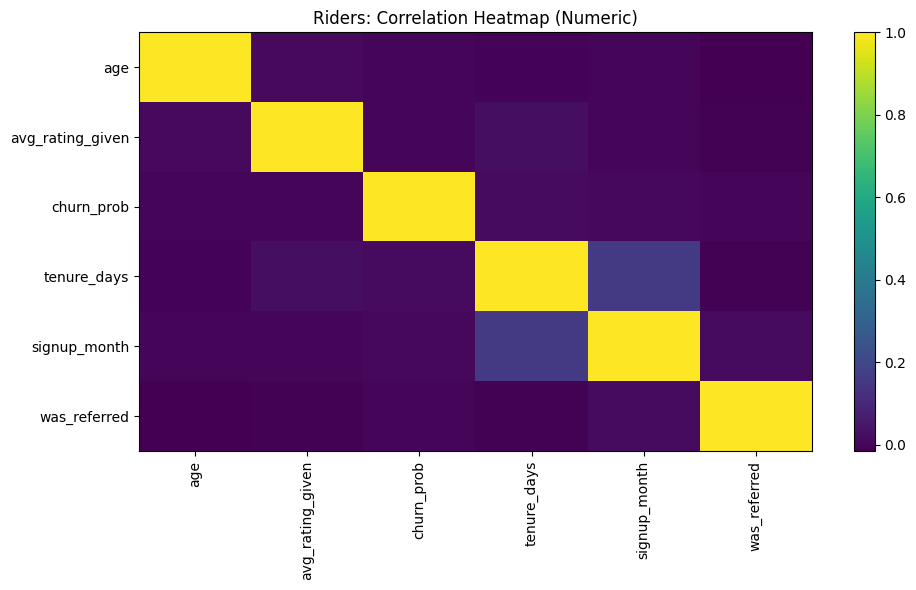

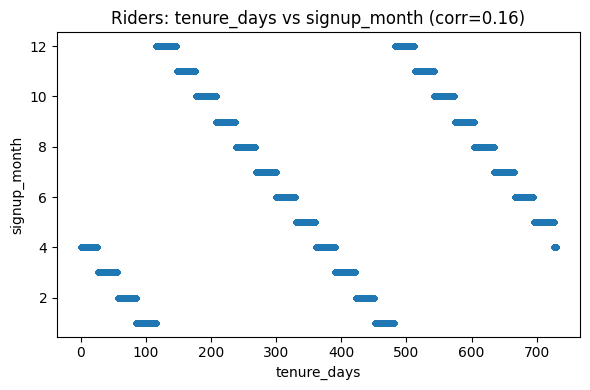

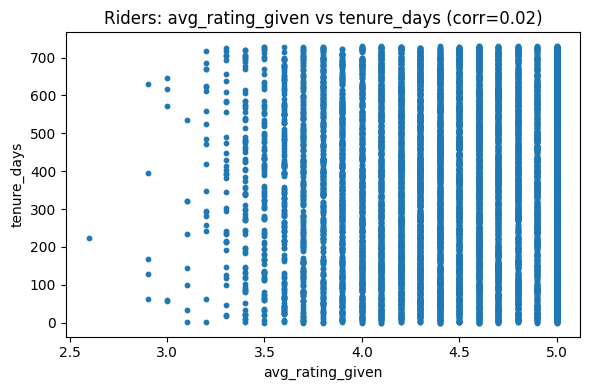

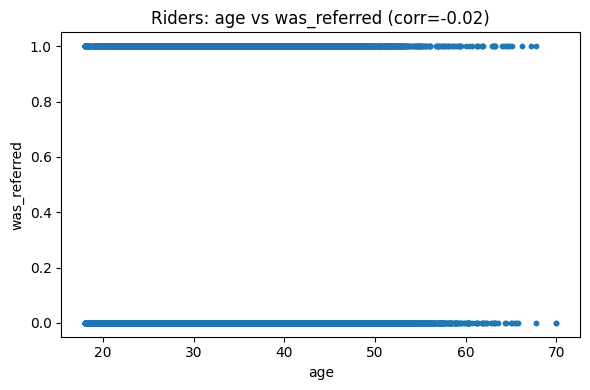

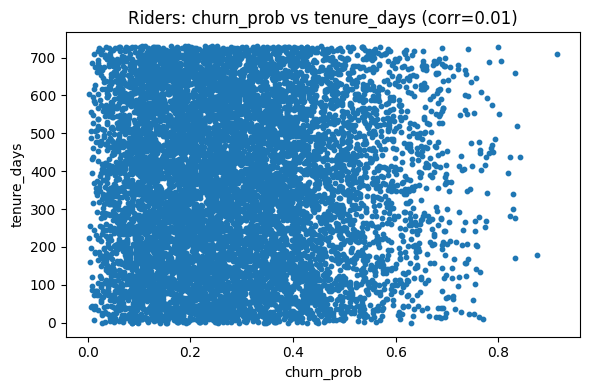

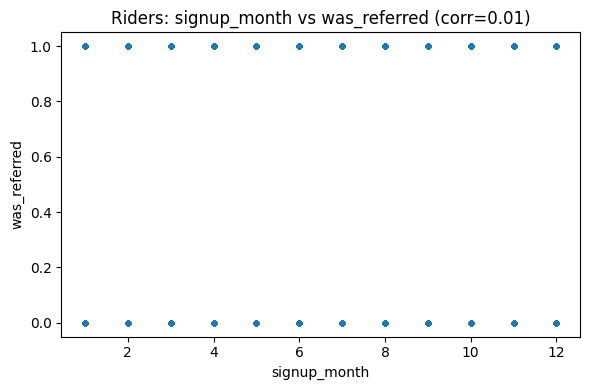

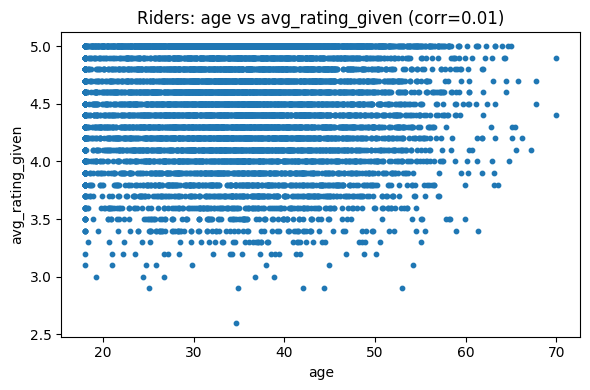

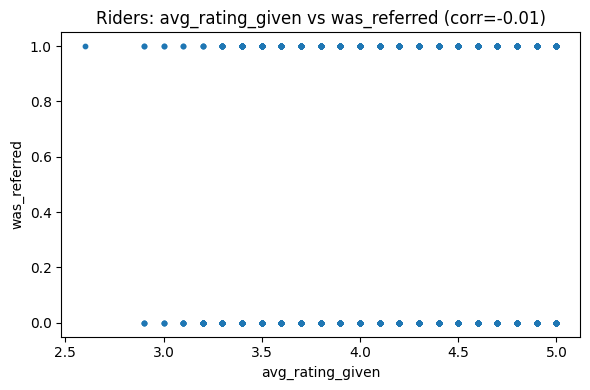

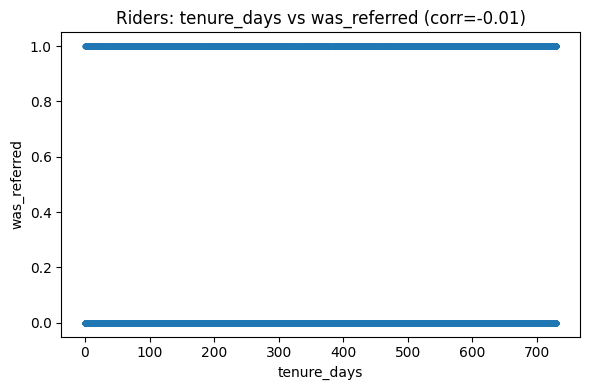

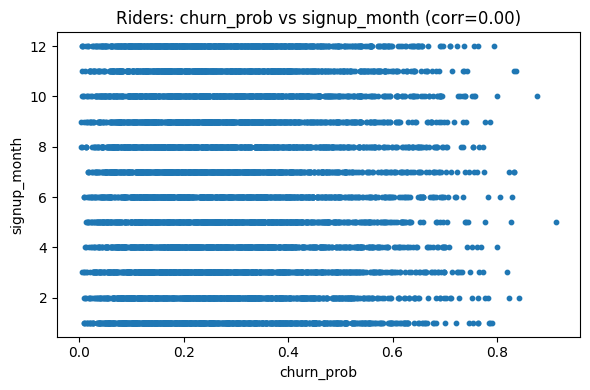

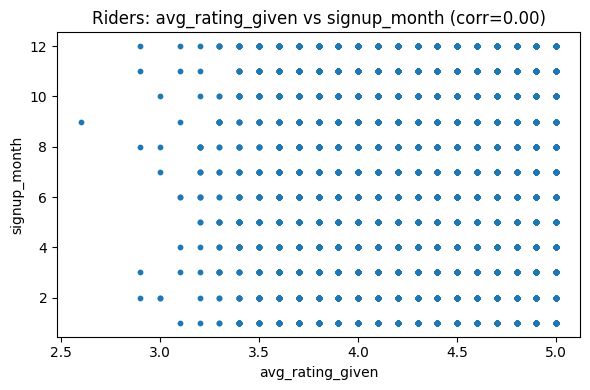


Riders — Numeric vs Categorical


C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


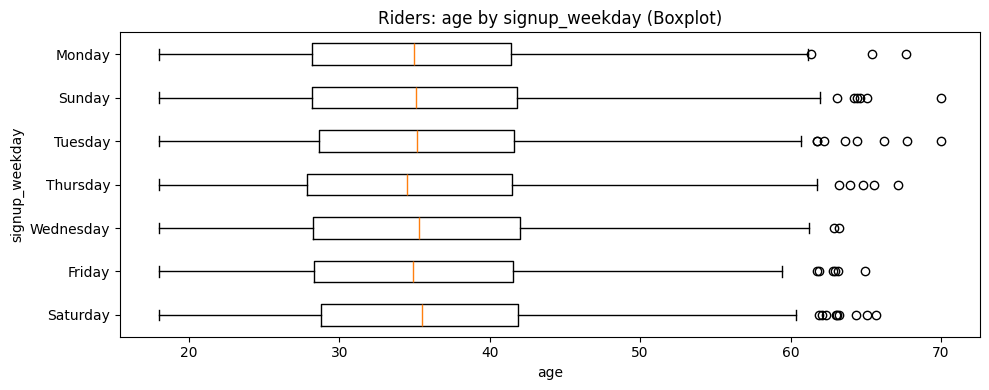

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


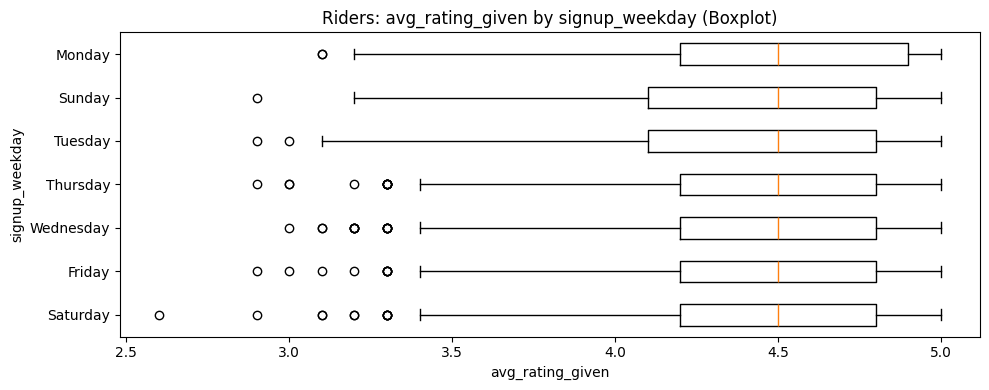

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


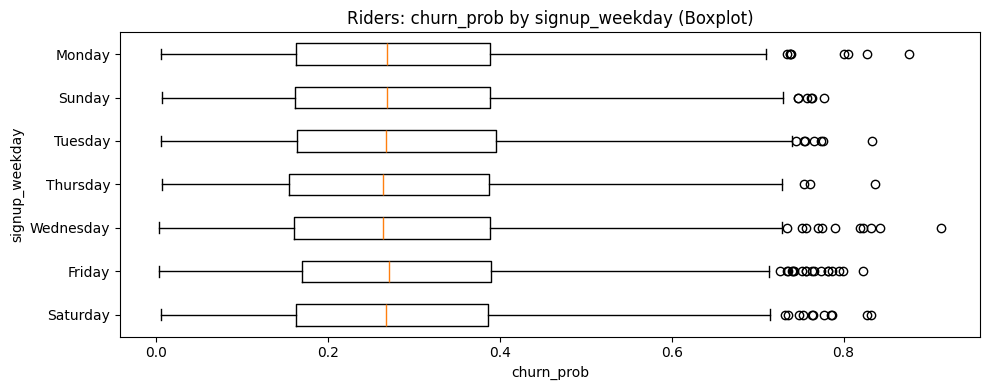

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


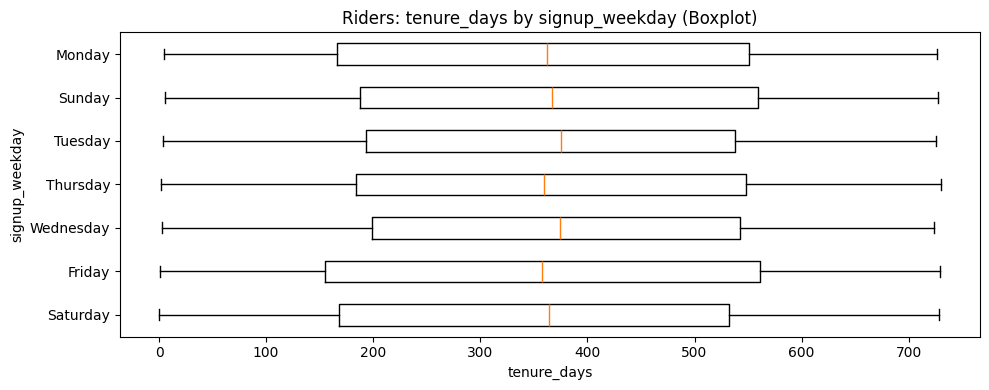

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


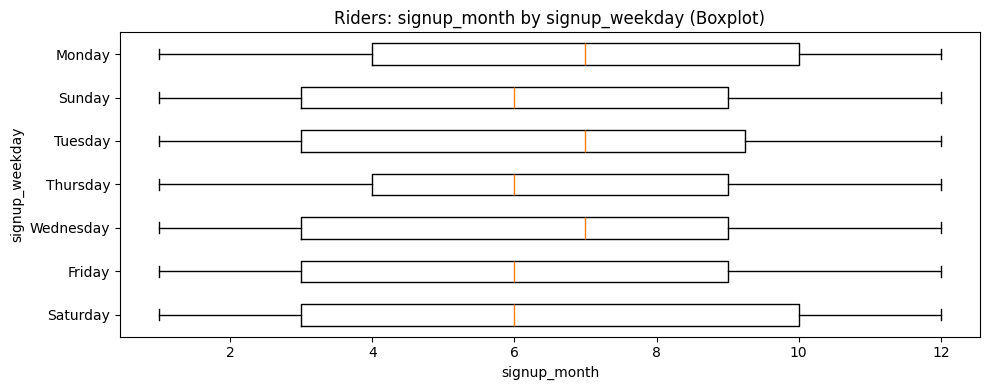

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


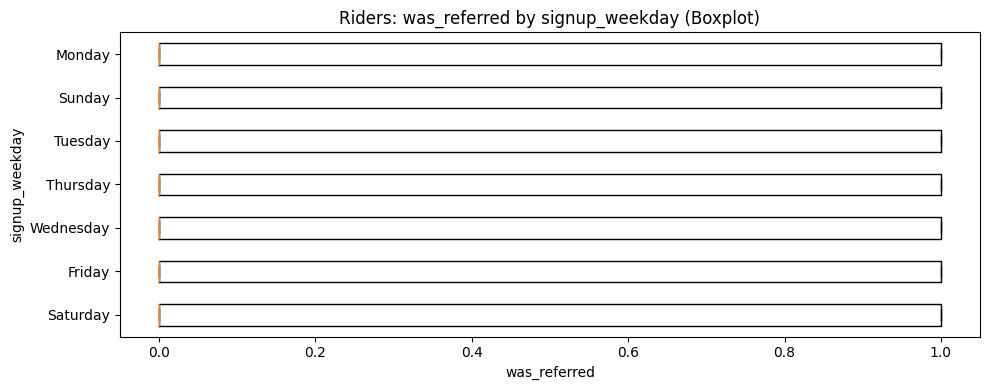

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  top_categories = df[cat].astype("object").fillna("MISSING").value_counts().head(top_n).index
C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_sub = df[df[cat].astype("object").fillna("MISSING").isin(top_categories)].copy()
C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated an

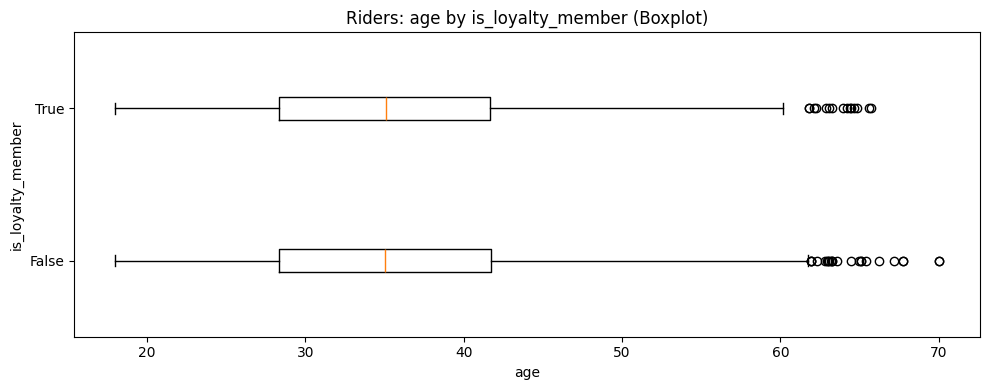

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


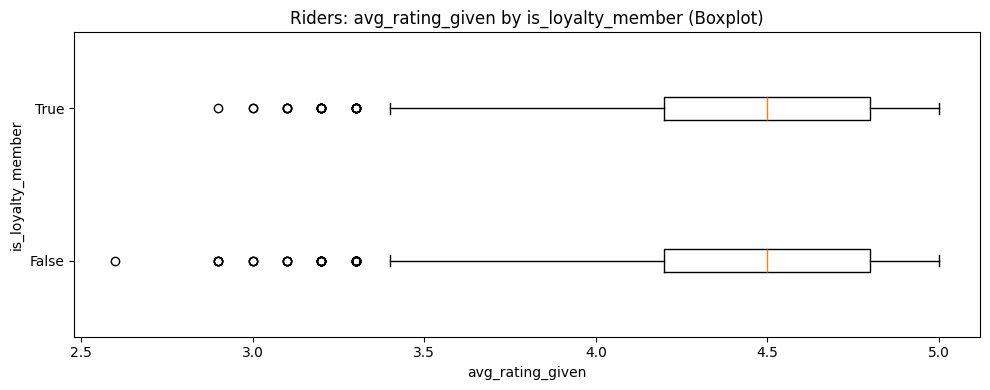

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


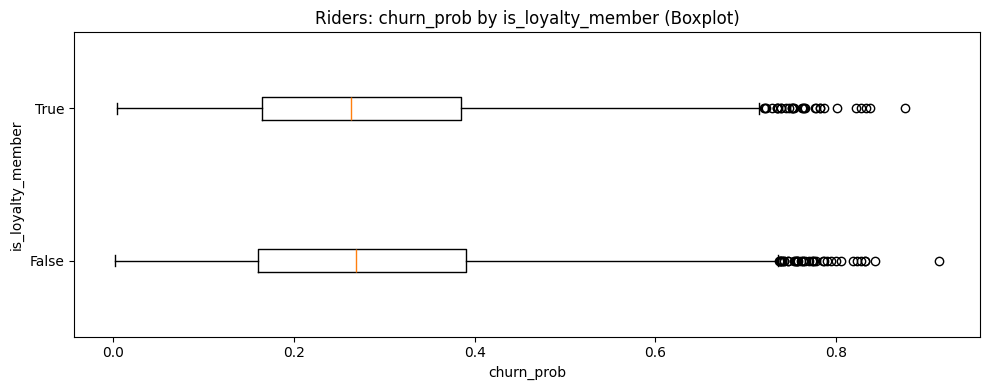

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


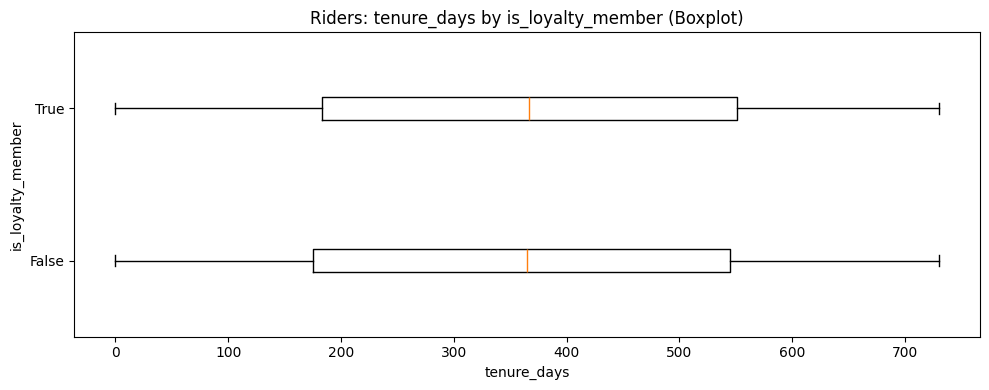

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


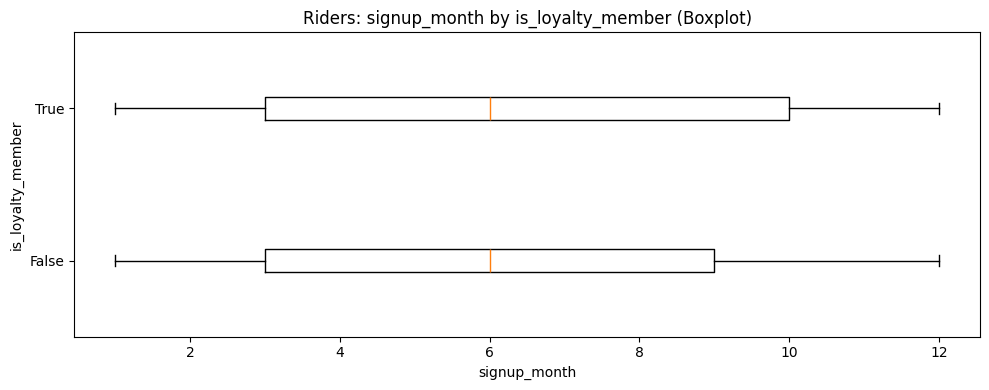

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


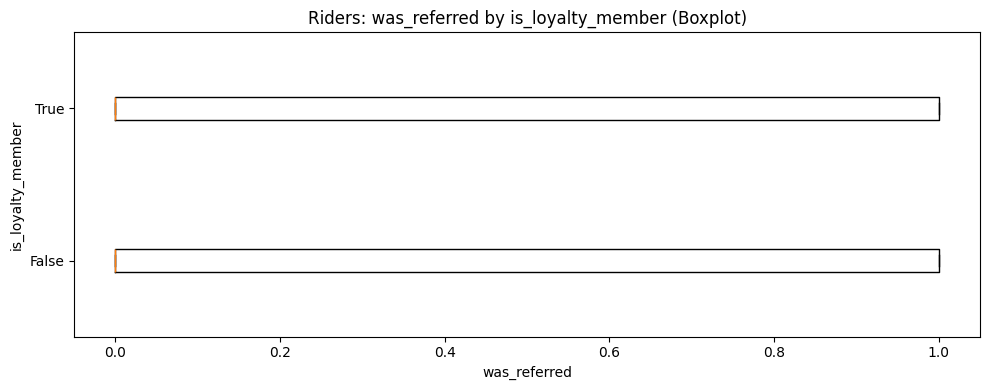

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


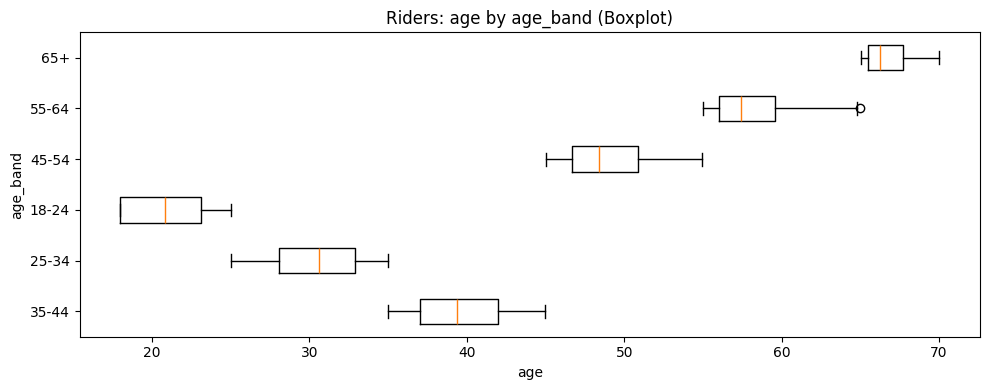

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


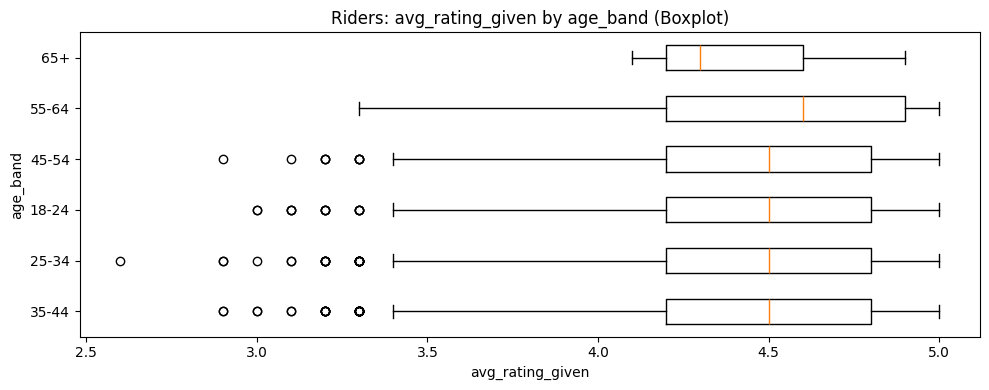

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


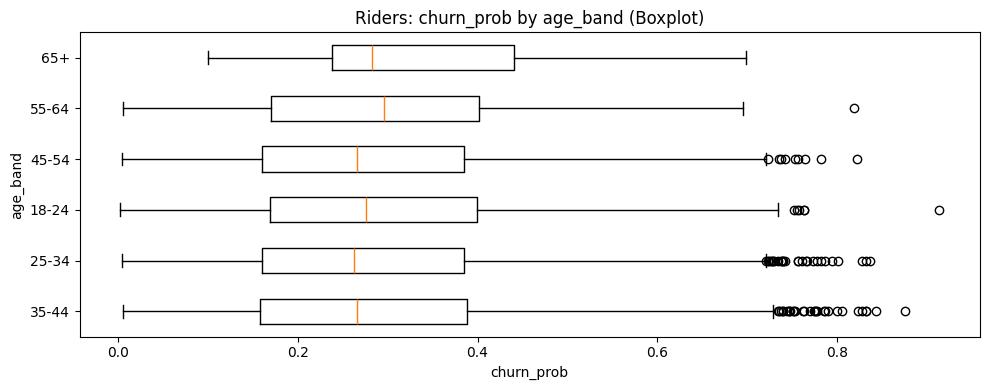

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


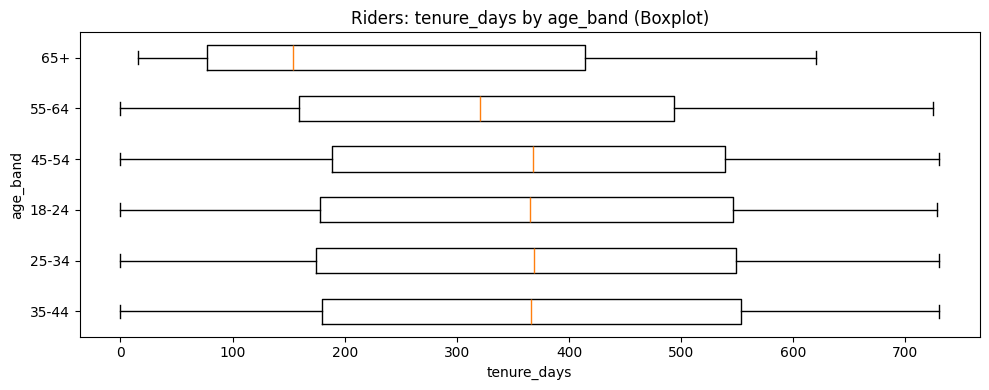

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


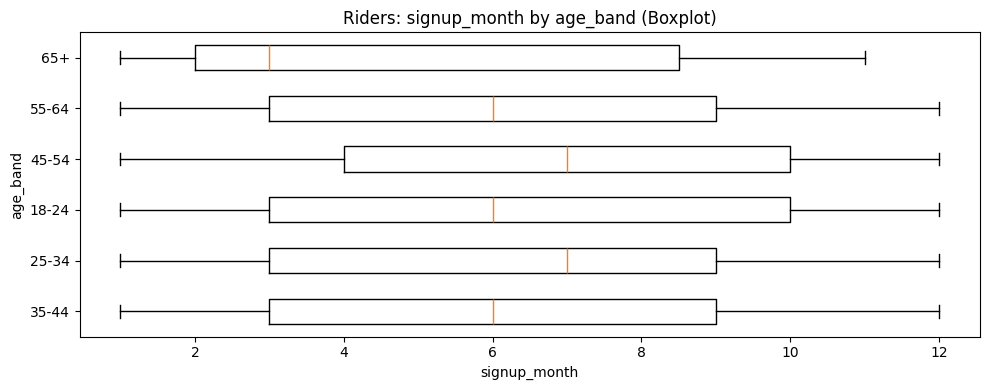

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\4251525054.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(x) for x in top_categories], vert=False)


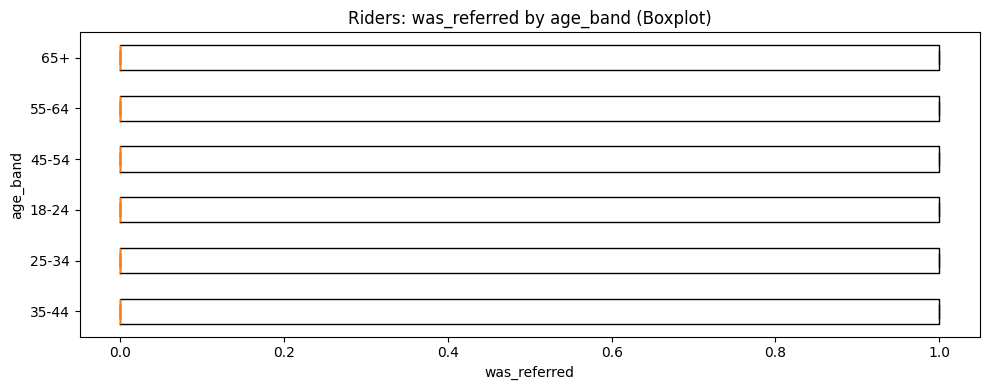

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\2779237777.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  top2 = df[c2].astype("object").fillna("MISSING").value_counts().head(top_n).index
C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\2779237777.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[c2].astype("object").fillna("MISSING").isin(top2)].copy()
C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\2779237777.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version.


Riders — Categorical vs Categorical


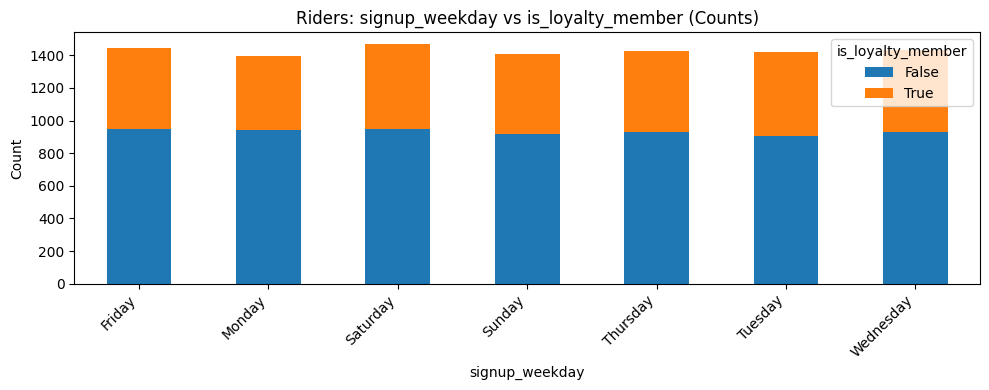

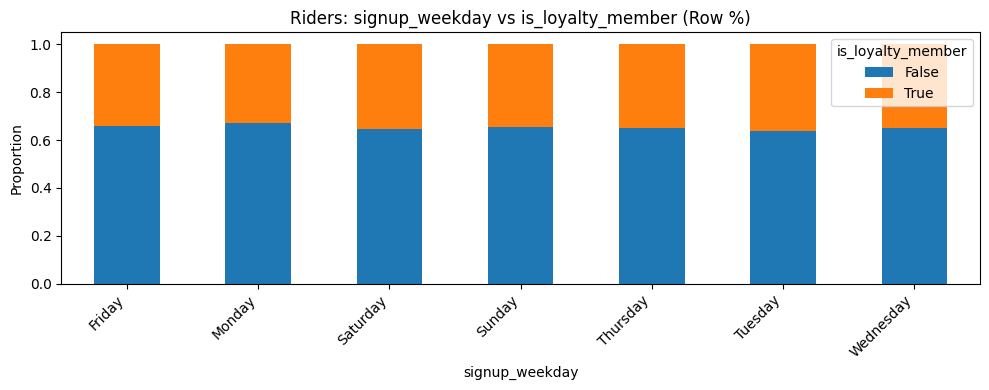

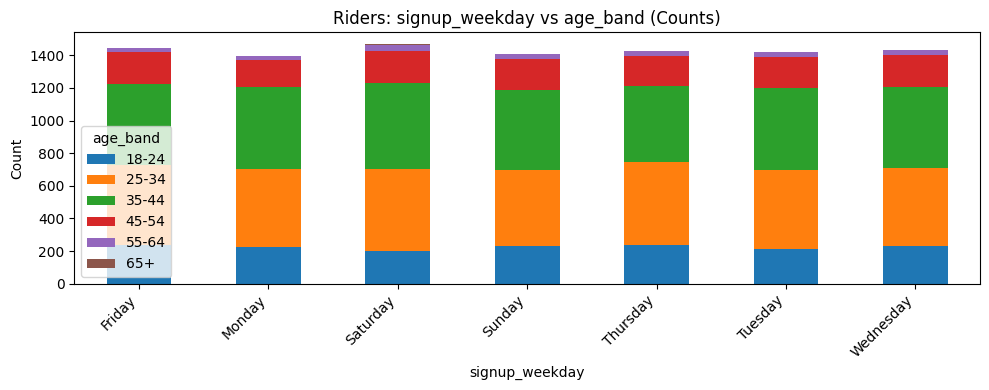

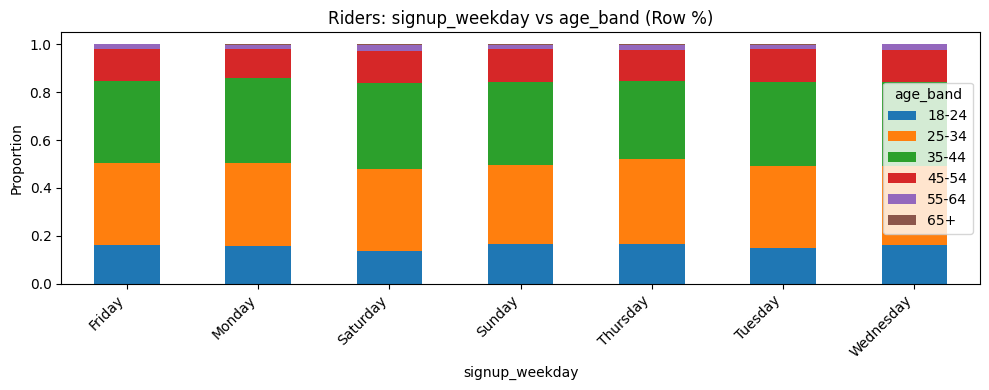

C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\2779237777.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  top1 = df[c1].astype("object").fillna("MISSING").value_counts().head(top_n).index
C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\2779237777.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub = df[df[c1].astype("object").fillna("MISSING").isin(top1) &
C:\Users\Admin\AppData\Local\Temp\ipykernel_9520\2779237777.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future versi

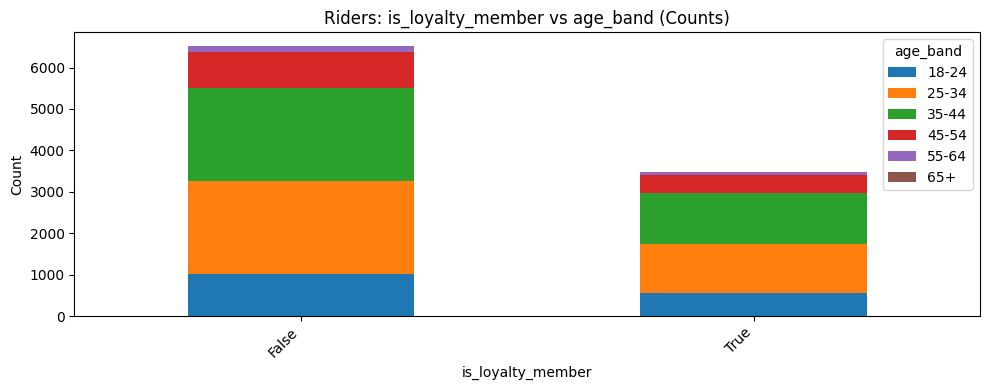

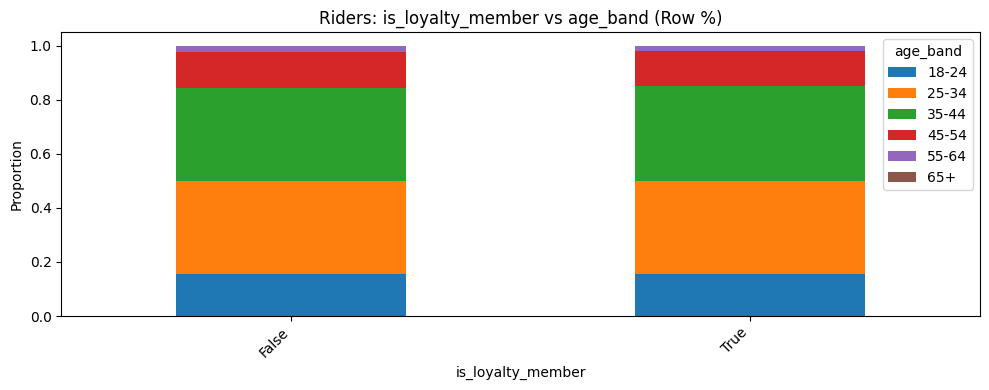


Riders — Bivariate vs TARGET (churn_prob)


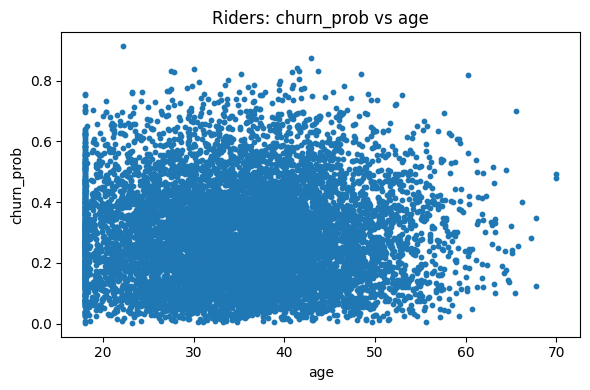

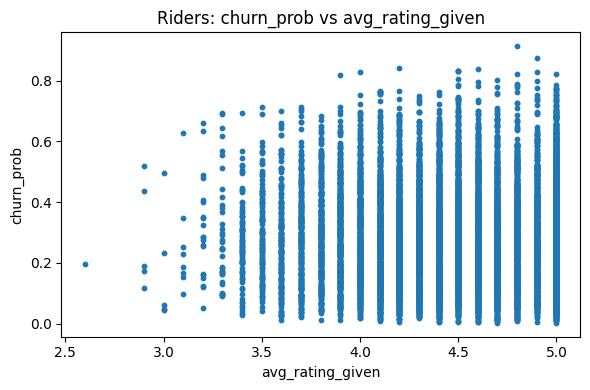

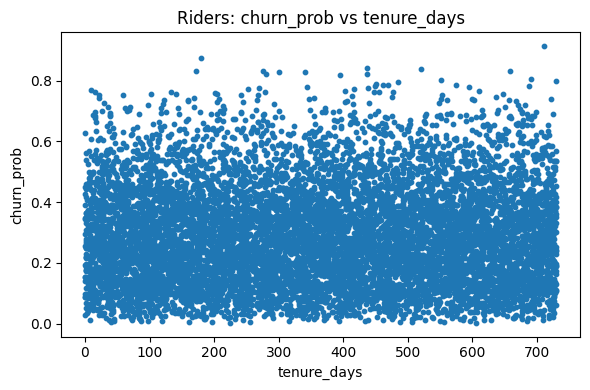

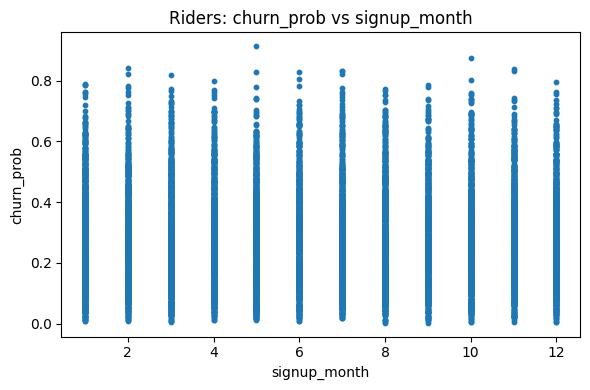

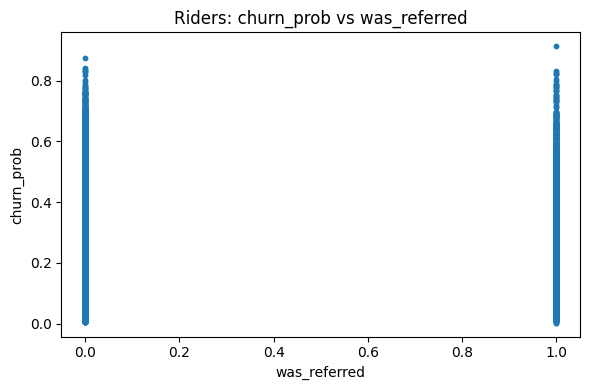


Trips — Numeric vs Numeric


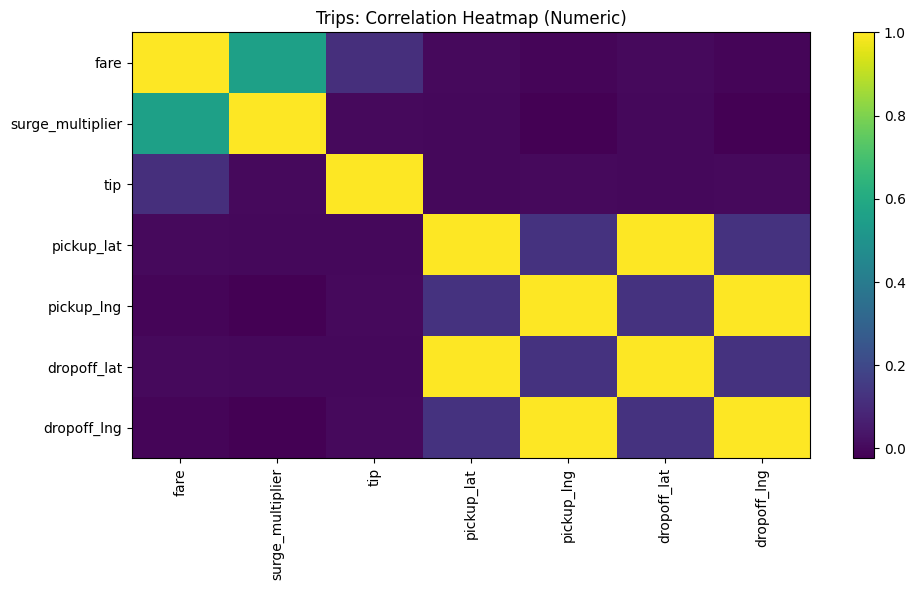

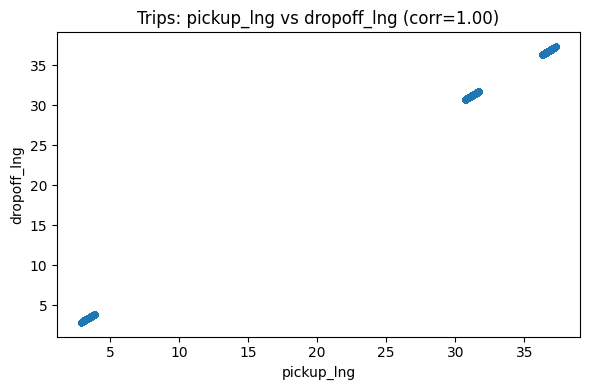

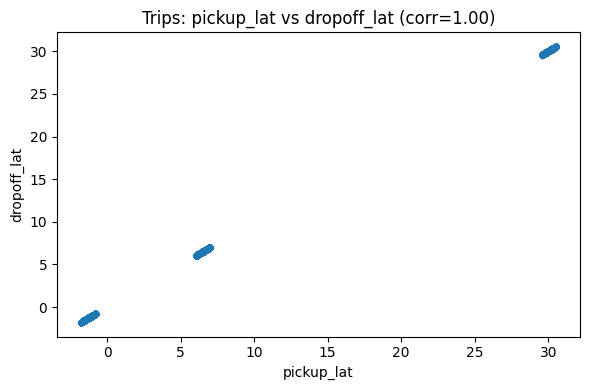

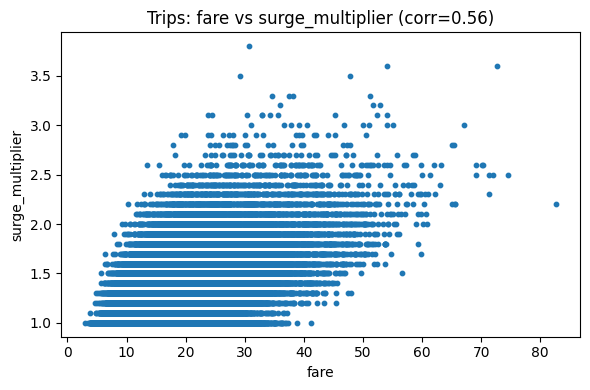

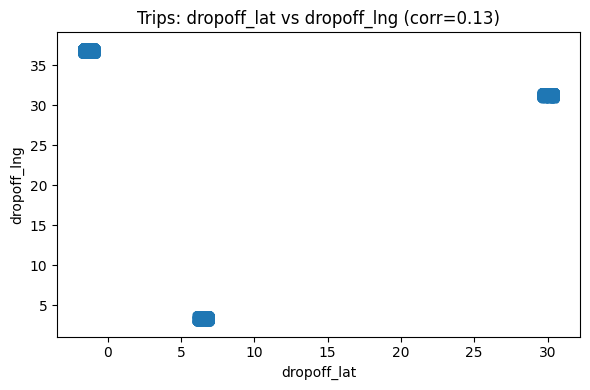

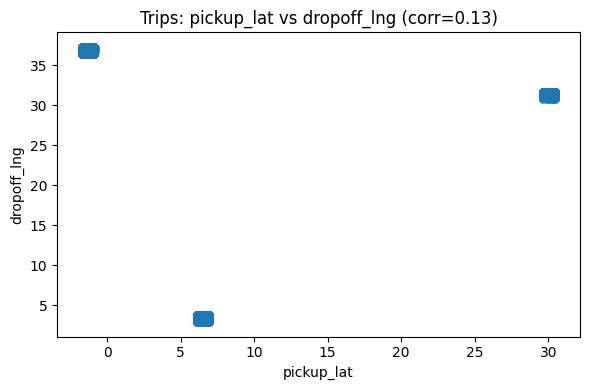

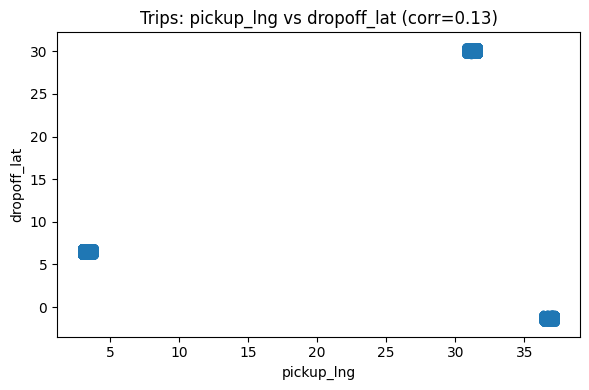

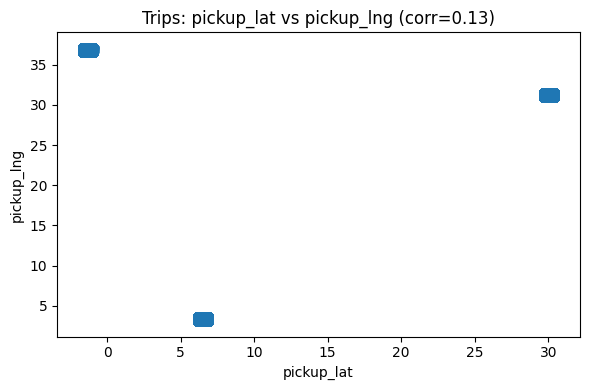

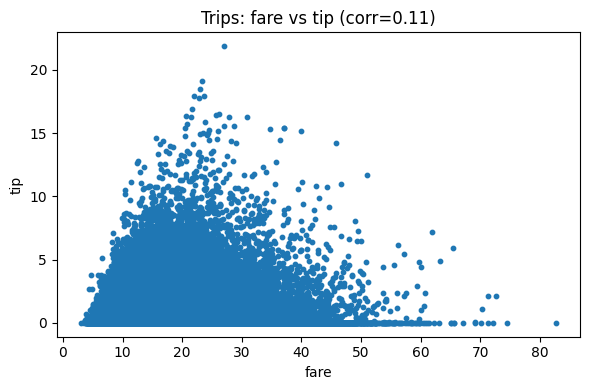

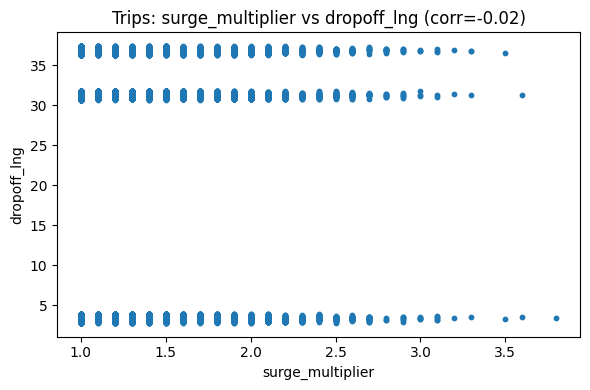

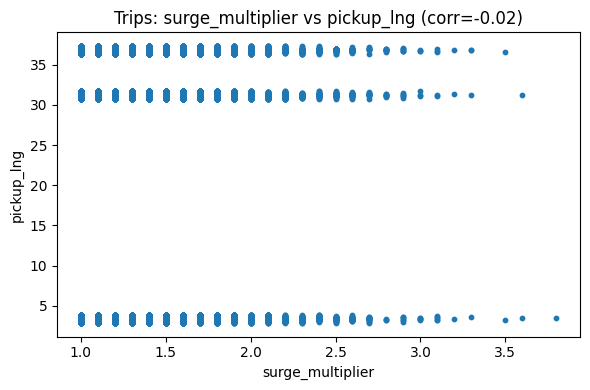

Trips: Need both numeric and categorical columns for numeric-vs-categorical.
Trips: Not enough categorical columns for categorical-vs-categorical.

Trips: No obvious churn target column found (e.g., churn/churned/is_churn/churn_prob). Skipping target-based plots.


In [18]:
# -----------------------------
# RUN BIVARIATE ANALYSIS
# -----------------------------
def run_bivariate(df, df_name):
    numeric_vs_numeric(df, df_name)
    numeric_vs_categorical(df, df_name)
    categorical_vs_categorical(df, df_name)
    bivariate_vs_target(df, df_name)

run_bivariate(riders, "Riders")
run_bivariate(trips, "Trips")

In [19]:

def run_multivariate(df, name):
    print(f"\n{'='*70}\nMULTIVARIATE ANALYSIS — {name.upper()}\n{'='*70}")

    target = detect_target(df)
    print("Detected target:", target)

    # ---------------- Correlation heatmap ----------------
    drop_for_corr = []
    if target and not pd.api.types.is_numeric_dtype(df[target]):
        drop_for_corr.append(target)

    corr, num_cols = corr_heatmap(df, name, drop_cols=drop_for_corr)
    top_corr_scatters(df, name, corr, num_cols, top_k=8)

    # ---------------- Target based analysis ----------------
    if target and corr is not None and len(num_cols) >= 3:

        temp_df = df.copy()

        # 🔥 Convert churn label safely to numeric if needed
        if not pd.api.types.is_numeric_dtype(temp_df[target]):
            unique_vals = temp_df[target].dropna().unique()

            if len(unique_vals) == 2:
                # binary label → map to 0/1
                temp_df[target] = (temp_df[target] == unique_vals[1]).astype(int)
            else:
                print(f"{name}: Target not binary → skipping target correlation.")
                target = None

        if target:
            # compute correlations safely
            corr_matrix = temp_df[num_cols + [target]].corr(numeric_only=True)

            if target in corr_matrix.columns:
                target_corr = corr_matrix[target].drop(target).abs().sort_values(ascending=False)
                top_feats = target_corr.head(3).index.tolist()
            else:
                top_feats = num_cols[:3]

            # 2D heatmap
            if len(top_feats) >= 2:
                target_2d_heatmap(temp_df, name, top_feats[0], top_feats[1], target, bins=10)

            # grouped churn rate
            possible_groups = [c for c in ["city", "loyalty_status", "age_band", "was_referred"] if c in temp_df.columns]
            if possible_groups:
                grouped_target_table(temp_df, name, target, group_cols=possible_groups[:2], top_n=10)

    # ---------------- Multicollinearity ----------------
    vif_table(df, name, drop_cols=[target] if target else [])


The exploratory analysis reveals that churn in RideWise is not driven by demographics, customer satisfaction, or pricing factors. Instead, churn is primarily behavioral and results from declining usage frequency. The platform operates as a habit-based service, where customers who fail to establish repeated usage patterns gradually disengage. Therefore, predictive modeling should emphasize engagement and recency-based features rather than customer profile attributes. Retention strategies should focus on re-activation and habit formation rather than experience improvement.